# The Sliding Window

## Introduction

In the previous two lessons, we learned about the three operations that carry out 
feature extraction from an image:

1. **Filter** — with a convolution layer
2. **Detect** — with ReLU activation  
3. **Condense** — with a maximum pooling layer

The convolution and pooling operations share a common feature: they are both performed 
over a **sliding window**.

| Operation | Layer | Window parameter |
|-----------|-------|-----------------|
| Filter (convolution) | `Conv2D` | `kernel_size` |
| Condense (pooling) | `MaxPool2D` | `pool_size` |



---

There are two additional parameters affecting both convolution and pooling layers:

- **`strides`** — how far the window should move at each step
- **`padding`** — how to handle the pixels at the edges of the input

With these two parameters, defining the two layers becomes:


In [1]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Conv2D(filters=64,
                  kernel_size=3,
                  strides=1,
                  padding='same',
                  activation='relu'),
    layers.MaxPool2D(pool_size=2,
                     strides=1,
                     padding='same')
    # More layers follow
])

---

## Stride

The distance the window moves at each step is called the **stride**. We specify it in 
both dimensions: left→right and top→bottom.





### Effect of stride on output:

| Layer | Typical stride | Why |
|-------|---------------|-----|
| `Conv2D` | `strides=1` | We want high-quality features — skipping pixels loses valuable info |
| `MaxPool2D` | `strides=2` or `strides=3` | We *want* to shrink the feature map |

> 💡 When stride is the same in both directions, you can write just one number:  
> `strides=(2, 2)` is the same as `strides=2`

---

## Padding

**The problem:** when the window reaches the edges of the image, it would hang off the border.  
The `padding` parameter decides what to do at these boundaries.

### `padding='valid'` — No padding (stay inside)

The window stays **entirely inside** the input. Edge pixels are simply skipped.




**Drawback:** output shrinks — larger kernels shrink it more. Limits how deep the network can be.

---

### `padding='same'` — Zero padding (pad the border)

Adds a border of **zeros** around the input so the window can sit over every pixel.  
Output size = same as input size.




**Drawback:** pixels at the border are "diluted" — they're averaged with artificial zeros.

---

### Trade-offs Summary

| | `padding='valid'` | `padding='same'` |
|---|---|---|
| Output size | Smaller than input | Same as input |
| Edge pixels | Ignored | Included (but diluted by zeros) |
| Use case | When shrinking is okay | When you need to preserve spatial size |
| Example model | — | **VGG** uses `'same'` for all conv layers |

> 🔑 Most modern convnets use **some combination** of both — another parameter to tune!


---

## Example — Exploring Sliding Windows

To better understand the effect of the sliding window parameters, it helps to observe 
feature extraction on a **low-resolution image** so we can see individual pixels clearly.

We'll use a simple circle and apply convolution with different stride and padding settings.


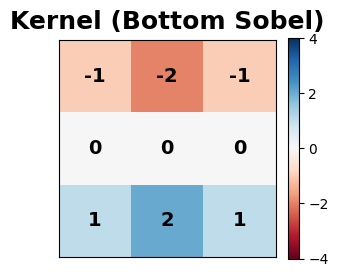

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')

# ── Replace circle() ───────────────────────────────────────────────────────────
def make_circle(size, val=1.0, r_shrink=3, thickness=1):
    h, w = size
    cx, cy = w // 2, h // 2
    radius = min(cx, cy) - r_shrink
    y, x = np.ogrid[:h, :w]
    dist = np.sqrt((x - cx)**2 + (y - cy)**2)
    mask = (dist >= radius - thickness) & (dist <= radius + thickness)
    img = np.zeros((h, w), dtype=np.float32)
    img[mask] = val
    return tf.constant(img)

image = make_circle([64, 64], val=1.0, r_shrink=3)
image = tf.reshape(image, [*image.shape, 1])   # → [64, 64, 1]

# ── Bottom Sobel kernel (detects horizontal edges — bottom direction) ──────────
kernel = tf.constant(
    [[-1, -2, -1],
     [ 0,  0,  0],
     [ 1,  2,  1]],
    dtype=tf.float32
)

# ── Replace show_kernel() ──────────────────────────────────────────────────────
def show_kernel(kernel, ax=None):
    k = kernel.numpy() if hasattr(kernel, 'numpy') else np.array(kernel)
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 3))
    im = ax.imshow(k, cmap='RdBu', vmin=-4, vmax=4)
    # Annotate each cell with its value
    for i in range(k.shape[0]):
        for j in range(k.shape[1]):
            ax.text(j, i, str(int(k[i, j])),
                    ha='center', va='center', fontsize=14,
                    color='black', fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('Kernel (Bottom Sobel)', pad=8)
    plt.colorbar(im, ax=ax, fraction=0.046)
    plt.show()

show_kernel(kernel)


The VGG architecture is fairly simple. It uses convolution with strides of 1 and maximum pooling with  
2
×
2
  windows and strides of 2. We've included a function in the visiontools utility script that will show us all the steps.

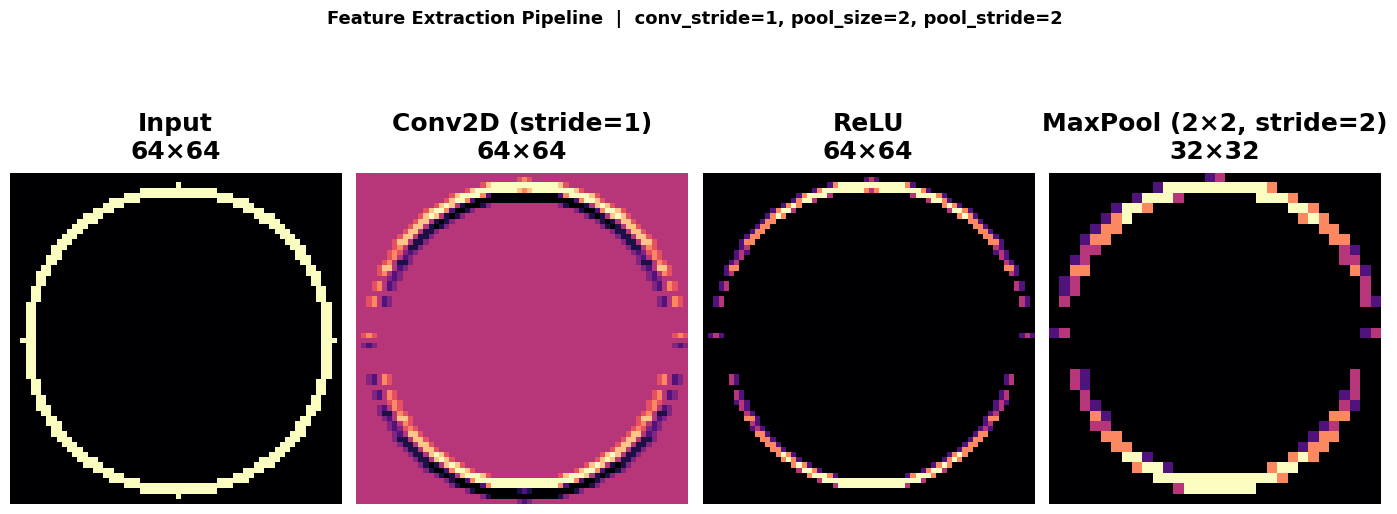

In [5]:
def show_extraction(image, kernel,
                    conv_stride=1,
                    pool_size=2,
                    pool_stride=2,
                    subplot_shape=(1, 4),
                    figsize=(14, 6)):
    """
    Shows the full feature extraction pipeline:
    Original → After Conv2D → After ReLU → After MaxPool2D
    """
    # Prepare image tensor: [1, H, W, 1]
    img = tf.cast(image, tf.float32)
    if len(img.shape) == 2:
        img = tf.reshape(img, [1, *img.shape, 1])
    elif len(img.shape) == 3:
        img = tf.reshape(img, [1, *img.shape])

    # Prepare kernel tensor: [H, W, 1, 1]
    k = tf.cast(kernel, tf.float32)
    if len(k.shape) == 2:
        k = tf.reshape(k, [*k.shape, 1, 1])

    # ── Step 1: Convolution (Filter) ──────────────────────────────────────────
    conv_out = tf.nn.conv2d(
        input=img,
        filters=k,
        strides=conv_stride,
        padding='SAME'
    )

    # ── Step 2: ReLU (Detect) ─────────────────────────────────────────────────
    relu_out = tf.nn.relu(conv_out)

    # ── Step 3: MaxPool (Condense) ────────────────────────────────────────────
    pool_out = tf.nn.pool(
        relu_out,
        window_shape=(pool_size, pool_size),
        strides=(pool_stride, pool_stride),
        padding='SAME',
        pooling_type='MAX'
    )

    # ── Plot ──────────────────────────────────────────────────────────────────
    images = [
        (tf.squeeze(img),      'Input\n{}×{}'.format(img.shape[1], img.shape[2])),
        (tf.squeeze(conv_out), 'Conv2D (stride={})\n{}×{}'.format(conv_stride, conv_out.shape[1], conv_out.shape[2])),
        (tf.squeeze(relu_out), 'ReLU\n{}×{}'.format(relu_out.shape[1], relu_out.shape[2])),
        (tf.squeeze(pool_out), 'MaxPool ({}×{}, stride={})\n{}×{}'.format(pool_size, pool_size, pool_stride, pool_out.shape[1], pool_out.shape[2])),
    ]

    fig, axes = plt.subplots(*subplot_shape, figsize=figsize)
    axes = axes.flatten()

    for ax, (img_data, title) in zip(axes, images):
        ax.imshow(img_data.numpy(), cmap='magma')
        ax.set_title(title)
        ax.axis('off')

    plt.suptitle(
        f'Feature Extraction Pipeline  |  conv_stride={conv_stride}, '
        f'pool_size={pool_size}, pool_stride={pool_stride}',
        fontsize=13, weight='bold', y=1.02
    )
    plt.tight_layout()
    plt.show()


# ── Run it ────────────────────────────────────────────────────────────────────
show_extraction(
    image, kernel,
    conv_stride=1,
    pool_size=2,
    pool_stride=2,
    subplot_shape=(1, 4),
    figsize=(14, 6),
)


And that works pretty well! The kernel was designed to detect horizontal lines, and we can see that in the resulting feature map the more horizontal parts of the input end up with the greatest activation.

What would happen if we changed the strides of the convolution to 3?

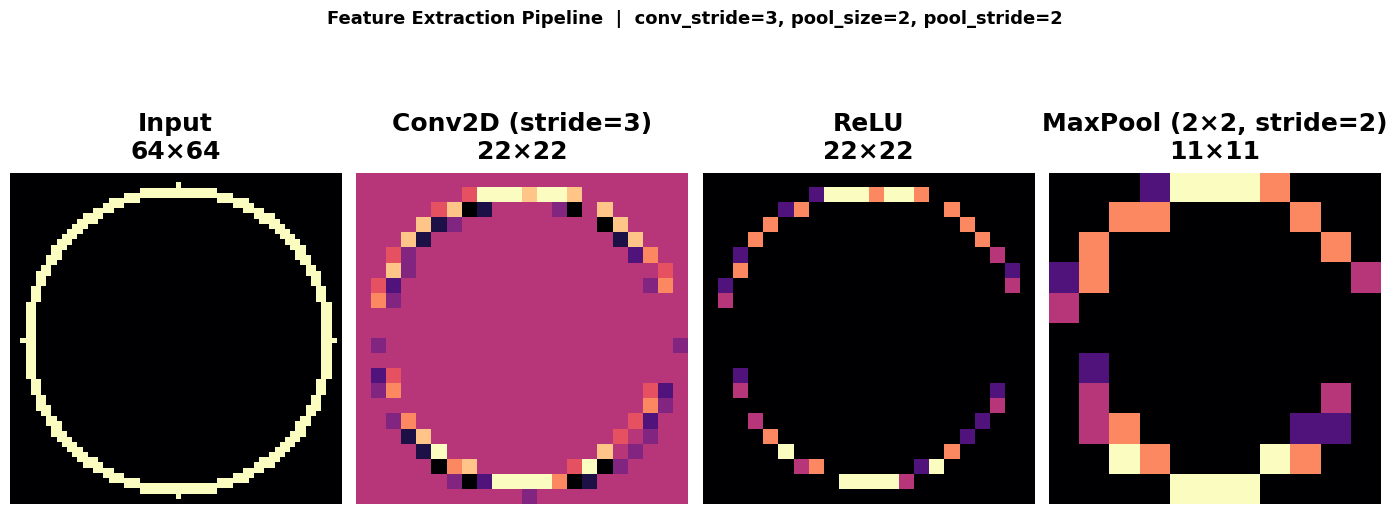

In [6]:
show_extraction(
    image, kernel,
    conv_stride=3,    # ← stride of 3 this time — skips more pixels
    pool_size=2,
    pool_stride=2,
    subplot_shape=(1, 4),
    figsize=(14, 6),
)


This seems to reduce the quality of the feature extracted. Our input circle is rather "finely detailed," being only 1 pixel wide. A convolution with strides of 3 is too coarse to produce a good feature map from it.

Sometimes, a model will use a convolution with a larger stride in it's initial layer. This will usually be coupled with a larger kernel as well. The ResNet50 model, for instance, uses  
7
×
7
  kernels with strides of 2 in its first layer. This seems to accelerate the production of large-scale features without the sacrifice of too much information from the input.

---

## The Receptive Field

Trace back all the connections from any neuron and you eventually reach the input image.  
All of the input pixels a neuron is connected to is that neuron's **receptive field** —  
it tells you which parts of the input image that neuron receives information from.

---

### Single Conv Layer (3×3 kernel)

Each neuron in the first layer sees a **3×3 patch** of the input:




---

### Two Stacked Conv Layers (both 3×3)

Add a second 3×3 conv layer. A neuron in the **second layer** sees a 3×3 patch of the 
**first layer** — but each first-layer neuron already covers a 3×3 input patch, and 
they **overlap** in a 5×5 region.




---

### Receptive Field Grows with Depth

Each additional 3×3 conv layer adds **2 pixels** to the receptive field in each direction:

| Layers | Receptive Field |
|--------|----------------|
| 1 × Conv(3×3) | **3×3** |
| 2 × Conv(3×3) | **5×5** |
| 3 × Conv(3×3) | **7×7** |
| N × Conv(3×3) | **(2N+1) × (2N+1)** |

> 🔑 **Key insight:** Stacking multiple small (3×3) kernels gives the same receptive field 
> as one large kernel — but with **fewer parameters** and **more non-linearities** (ReLU 
> after each layer). This is why modern networks like VGG use many 3×3 layers instead of 
> one big 7×7 or 11×11 layer.
